In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [ ]:
x = 6 * np.random.rand(200,1) - 3
y = 0.8 * x ** 2 + 0.9 * x + 2 + np.random.randn(200,1)

# y = 0.8x^2 + 0.9x + 2

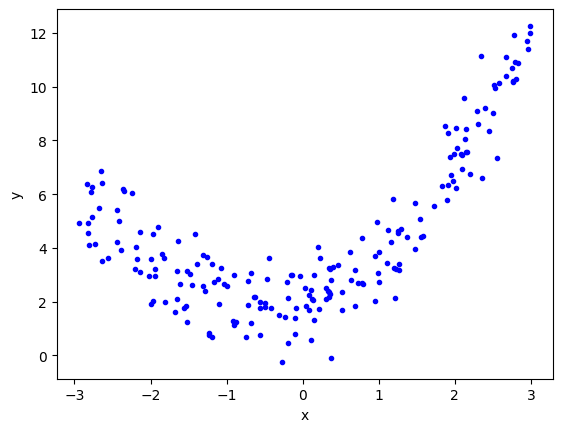

In [ ]:
plt.plot(x,y,'b.')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
lr = LinearRegression()

In [ ]:
lr.fit(x_train,y_train)

LinearRegression()

In [ ]:
print(lr.coef_)
print(lr.intercept_)

[[0.97670961]]
[4.39576419]


In [ ]:
y_pred = lr.predict(x_test)

In [ ]:
r2_score(y_test,y_pred)

0.46110502470977033

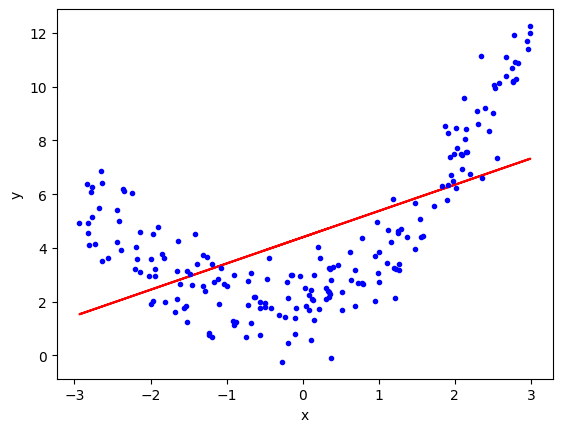

In [ ]:
plt.plot(x_train,lr.predict(x_train),color = 'red')
plt.plot(x,y,'b.')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [ ]:
# Apply Polynormal Regression

poly = PolynomialFeatures(degree=2)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

In [ ]:
print(x_train[0])
print(x_train_poly[0])

[-0.49432349]
[ 1.         -0.49432349  0.24435571]


In [ ]:
lr = LinearRegression()
lr.fit(x_train_poly,y_train)

LinearRegression()

In [ ]:
y_pred = lr.predict(x_test_poly)
r2_score(y_test,y_pred)

0.8045071886621424

In [ ]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.87901812 0.82123688]]
[2.02728229]


In [ ]:
x_new = np.linspace(-3,3,200).reshape(200,1)
x_new_poly = poly.transform(x_new)
y_new = lr.predict(x_new_poly)

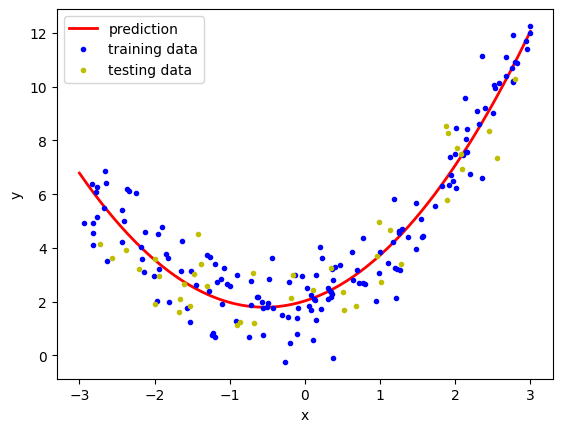

In [ ]:
plt.plot(x_new,y_new,'r-',linewidth=2,label='prediction')
plt.plot(x_train,y_train,'b.',label='training data')
plt.plot(x_test,y_test,'y.',label='testing data')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [ ]:
def polynomial_regression(degree):

    x_new = np.linspace(-3, 3, 100).reshape(100, 1)
    x_new_poly = poly.transform(x_new)

    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()

    polynomial_regression = Pipeline([
        ("poly_features", polybig_features),
        ("std_scaler", std_scaler),
        ("lin_reg", lin_reg),
    ])

    polynomial_regression.fit(x, y)

    y_newbig = polynomial_regression.predict(x_new)

    plt.plot(
        x_new,
        y_newbig,
        'r',
        label="Degree " + str(degree),
        linewidth=2
    )

    plt.plot(x_train, y_train, "b.", linewidth=3)
    plt.plot(x_test, y_test, "g.", linewidth=3)

    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")

    plt.axis([-3, 3, 0, 10])

    plt.show()

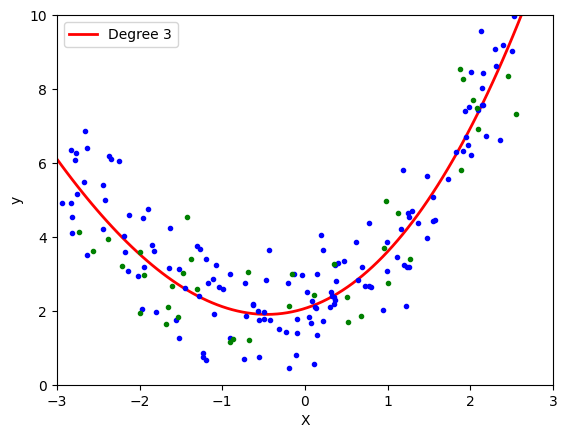

In [ ]:
polynomial_regression(degree=3)

In [ ]:
# 3D Polynomial Regression

x = 7 * np.random.rand(100,1) - 2.8
y = 7 * np.random.rand(100,1) - 2.8
z = x**2 + y**2 + 0.2 * x + 0.2 * y + 0.1 * x * y + 2 + np.random.rand(100,1)

In [ ]:
import plotly.express as px

df = px.data.iris()
fig = px.scatter_3d(df,x=x.ravel(),y=y.ravel(),z=z.ravel())
fig.show()

In [ ]:
lr = LinearRegression()
lr.fit(np.array([x,y]).reshape(100,2),z)

x_input = np.linspace(x.min(),x.max(),10)
y_input = np.linspace(y.min(),y.max(),10)

xgrid,ygrid = np.meshgrid(x_input,y_input)

final = np.vstack((xgrid.ravel(),ygrid.ravel().reshape(1,100))).T

z_final = lr.predict(final).reshape(10,10)

In [ ]:
import plotly.graph_objects as go

fig = px.scatter_3d(df,x=x.ravel(),y=y.ravel(),z=z.ravel())
fig.add_traces(go.Surface(x=x_input,y=y_input,z=z_final))
fig.show()

In [ ]:
x_multi = np.array([x,y]).reshape(100,2)
x_multi.shape

(100, 2)

In [ ]:
poly = PolynomialFeatures(degree=3)
x_multi_poly = poly.fit_transform(x_multi)


In [ ]:
print('Input :',poly.n_features_in_)
print('OUtput :',poly.n_output_features_)
print('Powers \n :',poly.powers_)

Input : 2
OUtput : 10
Powers 
 : [[0 0]
 [1 0]
 [0 1]
 [2 0]
 [1 1]
 [0 2]
 [3 0]
 [2 1]
 [1 2]
 [0 3]]


In [ ]:
x_multi_poly.shape

(100, 10)

In [ ]:
lr = LinearRegression()
lr.fit(x_multi_poly,z)

LinearRegression()

In [ ]:
x_test_poly = poly.transform(final)

In [ ]:
z_final = lr.predict(x_test_poly)

In [ ]:
fig = px.scatter_3d(x = x.ravel(),y=y.ravel(),z=z.ravel())
fig.add_traces(go.Surface(x=x_input,y=y_input,z=z_final.reshape(10,10)))
fig.update_layout(scene = dict(zaxis = dict(range = [0,35])))
fig.show()